<a href="https://colab.research.google.com/github/Tor4narek/AudioClassification/blob/main/sounds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Tor4narek/AudioClassification/blob/main/sounds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sound classifier from tabular audio features

This notebook prepares a neural network for 4 sound classes: `gunshot`, `sirena`, `dog_bark`, `children`.

Data is loaded from `X_y_basic_readable.xlsx`, sheet `dataset_basic`. Training is disabled by default with `RUN_TRAINING = False`.


In [1]:
try:
    import openpyxl  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl"])


In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
DATA_PATH = "/content/drive/MyDrive/ai/X_y_basic_readable.xlsx"
OUTPUT_DIR = "/content/drive/MyDrive/ai"
SHEET_NAME = "dataset_basic"
RUN_TRAINING = True

FEATURE_COLUMNS = [
    "rms_mean",
    "active_duration",
    "rms_peak_to_mean",
    "attack_time",
    "zcr_mean",
    "spectral_centroid_mean",
    "spectral_bandwidth_mean",
    "spectral_rolloff_mean",
]

CLASS_NAMES = ["gunshot", "sirena", "dog_bark", "children"]
SEED = 42
VALIDATION_SIZE = 0.2
BATCH_SIZE = 16
EPOCHS = 80


In [15]:
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

required_columns = FEATURE_COLUMNS + CLASS_NAMES
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

empty_counts = df[required_columns].isna().sum()
if empty_counts.any():
    raise ValueError(f"Missing values found:\n{empty_counts[empty_counts > 0]}")

class_row_sums = df[CLASS_NAMES].sum(axis=1)
invalid_rows = df.index[class_row_sums != 1].tolist()
if invalid_rows:
    raise ValueError(f"Each row must have exactly one active class. Bad row indexes: {invalid_rows[:20]}")

print("Dataset shape:", df.shape)
print("Class balance:")
display(df[CLASS_NAMES].sum().rename("count").to_frame())

df.head()


Dataset shape: (200, 12)
Class balance:


,count
gunshot,50
sirena,50
dog_bark,50
children,50


,rms_mean,active_duration,rms_peak_to_mean,attack_time,zcr_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,gunshot,sirena,dog_bark,children
0,0.056470,0.859138,4.755143,0.487619,0.056960,1427.121003,2159.521170,2870.109194,1,0,0,0
1,0.066237,1.532517,3.076957,0.325079,0.090178,1490.825138,1452.156142,2477.268354,1,0,0,0
2,0.044986,0.371519,6.246018,0.069660,0.074046,1963.946897,2069.311815,4191.096608,1,0,0,0
3,0.105513,0.859138,3.147509,0.116100,0.119781,2413.703124,2332.338456,4862.797371,1,0,0,0
4,0.082683,0.859138,3.817054,0.069660,0.111220,2363.304039,2286.762742,4698.992365,1,0,0,0


In [16]:
X = df[FEATURE_COLUMNS].astype("float32").to_numpy()
y = df[CLASS_NAMES].astype("float32").to_numpy()
y_labels = np.argmax(y, axis=1)

X_train, X_val, y_train, y_val, labels_train, labels_val = train_test_split(
    X,
    y,
    y_labels,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_labels,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_val_scaled = scaler.transform(X_val).astype("float32")

print("X_train:", X_train_scaled.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val_scaled.shape)
print("y_val:", y_val.shape)


X_train: (160, 8)
y_train: (160, 4)
X_val: (40, 8)
y_val: (40, 4)


In [17]:
tf.keras.utils.set_random_seed(SEED)

model = keras.Sequential(
    [
        keras.Input(shape=(len(FEATURE_COLUMNS),), name="audio_features"),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(len(CLASS_NAMES), activation="softmax", name="sound_class"),
    ],
    name="sound_classifier",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sound_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sound_class (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,044 (11.89 KB)

 Trainable params: 2,916 (11.39 KB)

 Non-trainable params: 128 (512.00 B)

In [18]:
history = None

if RUN_TRAINING:
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
else:
    print("Training is disabled: RUN_TRAINING = False")


Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - accuracy: 0.2937 - loss: 1.8986 - val_accuracy: 0.5250 - val_loss: 1.2807
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4313 - loss: 1.4480 - val_accuracy: 0.5250 - val_loss: 1.2080
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 1.1860 - val_accuracy: 0.6000 - val_loss: 1.1488
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5562 - loss: 1.0332 - val_accuracy: 0.6250 - val_loss: 1.0957
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6625 - loss: 0.8713 - val_accuracy: 0.6500 - val_loss: 1.0490
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6687 - loss: 0.8246 - val_accuracy: 0.7750 - val_loss: 1.0095
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 0.7679 - val_accuracy: 0.7500 - val_loss: 0.9741
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7125 - loss: 0.7170 - val_accuracy: 0.7500 - 

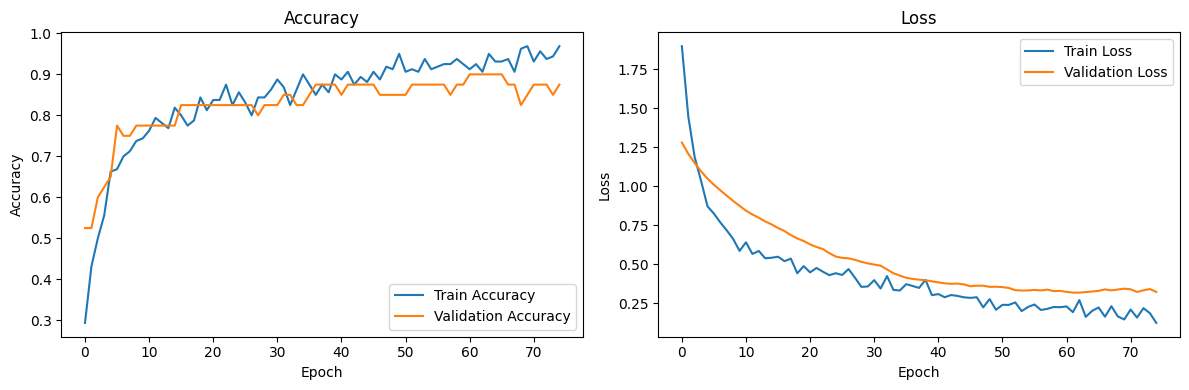

In [19]:
if history is not None:
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["accuracy"], label="Train Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")

    plt.tight_layout()
    plt.show()
else:
    print("Training charts will appear after model.fit runs.")


Validation loss: 0.3176
Validation accuracy: 0.9000


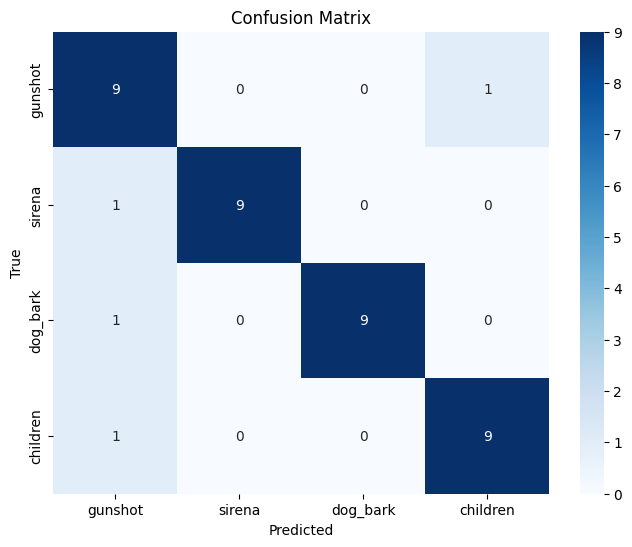

              precision    recall  f1-score   support

     gunshot       0.75      0.90      0.82        10
      sirena       1.00      0.90      0.95        10
    dog_bark       1.00      0.90      0.95        10
    children       0.90      0.90      0.90        10

    accuracy                           0.90        40
   macro avg       0.91      0.90      0.90        40
weighted avg       0.91      0.90      0.90        40



In [20]:
if RUN_TRAINING:
    loss, accuracy = model.evaluate(X_val_scaled, y_val, verbose=0)
    print(f"Validation loss: {loss:.4f}")
    print(f"Validation accuracy: {accuracy:.4f}")

    probabilities = model.predict(X_val_scaled, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = np.argmax(y_val, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap="Blues",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
else:
    print("Evaluation is skipped because RUN_TRAINING = False")


In [26]:
def predict_sound(
    rms_mean,
    active_duration,
    rms_peak_to_mean,
    attack_time,
    zcr_mean,
    spectral_centroid_mean,
    spectral_bandwidth_mean,
    spectral_rolloff_mean,
):
    """Return predicted class and probabilities for 8 audio features."""
    features = np.array(
        [[
            rms_mean,
            active_duration,
            rms_peak_to_mean,
            attack_time,
            zcr_mean,
            spectral_centroid_mean,
            spectral_bandwidth_mean,
            spectral_rolloff_mean,
        ]],
        dtype="float32",
    )

    scaled_features = scaler.transform(features).astype("float32")
    probabilities = model.predict(scaled_features, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))

    return {
        "predicted_class": CLASS_NAMES[predicted_index],
        "probabilities": {
            class_name: float(probability)
            for class_name, probability in zip(CLASS_NAMES, probabilities)
        },
    }

sirena_result = predict_sound(
    rms_mean=0.221244,
    active_duration=3.652963,
    rms_peak_to_mean=1.746532,
    attack_time=1.601248,
    zcr_mean=0.092404,
    spectral_centroid_mean=1484.82,
    spectral_bandwidth_mean=1341.852,
    spectral_rolloff_mean=2316.453,
)

dog_bark_result = predict_sound(
    rms_mean=0.094178,
    active_duration=1.27524,
    rms_peak_to_mean=5.149717,
    attack_time=1.100161,
    zcr_mean=0.096774,
    spectral_centroid_mean=1930.711,
    spectral_bandwidth_mean=2035.28,
    spectral_rolloff_mean=3701.993,
)

children_result = predict_sound(
    rms_mean=0.128697,
    active_duration=3.47417,
    rms_peak_to_mean=2.554397,
    attack_time=2.215648,
    zcr_mean=0.143168,
    spectral_centroid_mean=2352.965,
    spectral_bandwidth_mean=2081.423,
    spectral_rolloff_mean=4382.801,
)

print("sirena:", sirena_result)
print("dog_bark:", dog_bark_result)
print("children:", children_result)
# Example after training:
#predict_sound(0.05, 0.85, 4.75, 0.48, 0.05, 1427.12, 2159.52, 2870.10)


sirena: {'predicted_class': 'sirena', 'probabilities': {'gunshot': 0.0020405512768775225, 'sirena': 0.9906766414642334, 'dog_bark': 0.003197968937456608, 'children': 0.0040849242359399796}}
dog_bark: {'predicted_class': 'dog_bark', 'probabilities': {'gunshot': 0.46963801980018616, 'sirena': 0.013027842156589031, 'dog_bark': 0.4944213628768921, 'children': 0.022912750020623207}}
children: {'predicted_class': 'children', 'probabilities': {'gunshot': 0.02223202772438526, 'sirena': 0.00569208525121212, 'dog_bark': 0.08762115240097046, 'children': 0.8844546675682068}}


In [23]:
if RUN_TRAINING:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    model_path = os.path.join(OUTPUT_DIR, "sound_classifier_model.keras")
    class_names_path = os.path.join(OUTPUT_DIR, "class_names.json")
    scaler_params_path = os.path.join(OUTPUT_DIR, "scaler_params.json")

    model.save(model_path)

    with open(class_names_path, "w", encoding="utf-8") as f:
        json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

    scaler_params = {
        "feature_columns": FEATURE_COLUMNS,
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
    }
    with open(scaler_params_path, "w", encoding="utf-8") as f:
        json.dump(scaler_params, f, ensure_ascii=False, indent=2)

    print("Model and metadata saved:")
    print(model_path)
    print(class_names_path)
    print(scaler_params_path)
else:
    print("Saving is skipped because RUN_TRAINING = False")


Model and metadata saved:
/content/drive/MyDrive/ai/sound_classifier_model.keras
/content/drive/MyDrive/ai/class_names.json
/content/drive/MyDrive/ai/scaler_params.json
